In [1]:
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install thop torchmetrics seaborn scikit-learn pandas matplotlib

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 70.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 44.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 96.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 3.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 11.1 MB/s eta 0:00:0000

# Task 2 — Supervised Baselines from Related Work
**Objective:** Evaluate pre-trained supervised backbones (e.g., ResNet-50).

**Constraints Met:**
* **Splits:** 10:90 (Train+Val : Test). Internal validation is 10% of the training portion.
* **Training:** Max 50 epochs.
* **Metrics:** Accuracy, Precision, Recall, F1, ROC-AUC, Wall-clock time, GFLOPs.
* **Visuals:** Learning curves, ROC curves, and Confusion Matrices.

In [2]:
import os
import time
import copy
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from thop import profile

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")

Using compute device: cuda


In [3]:
# 1. Extract Dataset (Update 'dataset.zip' to your Kaggle input path if needed)
zip_path = 'dataset.zip' 
extract_dir = '/kaggle/input/datasets/gazimdjubayer/prbd-rice-microscopic-dataset/PRBD Microscopic Image of Different Processed Rice/Original_Images'

if not os.path.exists(extract_dir):
    print("Extracting dataset...")
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
    except FileNotFoundError:
        print(f"Please ensure {zip_path} is uploaded to your Kaggle working directory.")

# 2. Define Transforms (Fixed input size: 224x224)
input_size = 224
data_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(extract_dir, transform=data_transforms)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Discovered {num_classes} classes: {class_names}")

# 3. Strict 10:90 Ratio Splitting
total_size = len(full_dataset)
test_size = int(0.90 * total_size)
train_val_size = total_size - test_size

# Global Split
train_val_dataset, test_dataset = random_split(
    full_dataset, [train_val_size, test_size], generator=torch.Generator().manual_seed(42)
)

# Internal Train/Val Split (10% of Train+Val allocated to Validation)
val_size = int(0.10 * train_val_size)
train_size = train_val_size - val_size

train_dataset, val_dataset = random_split(
    train_val_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

print(f"Final Data Split -> Train: {train_size}, Validation: {val_size}, Test: {test_size}")

# 4. DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

Discovered 10 classes: ['Aush', 'BR-28', 'BR-29', 'Beroi', 'Chinigura', 'Ghee Bhog', 'Katari Najir', 'Katari Siddho', 'Miniket', 'Swarna']
Final Data Split -> Train: 180, Validation: 20, Test: 1800


In [4]:
def get_models(num_classes):
    models_dict = {
        # Using ResNet50 as the primary backbone
        'ResNet50': models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1) 
    }

    # Adapt classification heads for ResNet
    if 'ResNet50' in models_dict:
        models_dict['ResNet50'].fc = nn.Linear(models_dict['ResNet50'].fc.in_features, num_classes)

    return models_dict

def calculate_gflops(model, input_size=(1, 3, 224, 224)):
    """Safely calculate GFLOPs on CPU."""
    model.eval()
    cpu_device = torch.device("cpu")
    dummy_input = torch.randn(input_size).to(cpu_device)
    model = model.to(cpu_device)
    
    macs, _ = profile(model, inputs=(dummy_input, ), verbose=False)
    
    model = model.to(device)
    return macs / 1e9

In [5]:
def train_model(model, model_name, criterion, optimizer, num_epochs=50):
    model = model.to(device)
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    start_time = time.time()
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}', end=' | ')
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            if phase == 'val':
                print(f'Val Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
                
                # Check based on plateauing but DOES NOT trigger an early exit
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - start_time
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    
    # Load best model weights so evaluation uses the best weights, not the overfit ones
    model.load_state_dict(best_model_wts)
    return model, history, time_elapsed

In [6]:
def evaluate_and_plot(model, model_name, dataloader, num_classes):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    # Time the evaluation phase
    start_time = time.time()
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    test_time = time.time() - start_time
            
    # Calculate Sklearn Metrics
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )
    
    # Binarize labels for multi-class ROC-AUC
    labels_bin = label_binarize(all_labels, classes=range(num_classes))
    
    if num_classes == 2:
        roc_auc = roc_auc_score(all_labels, [p[1] for p in all_probs])
    else:
        roc_auc = roc_auc_score(labels_bin, all_probs, average='macro', multi_class='ovr')
        
    # Plot 1: Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.show()
    
    # Plot 2: ROC Curve (One-vs-Rest for each class)
    plt.figure(figsize=(8, 6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], np.array(all_probs)[:, i])
        plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {auc(fpr, tpr):.2f})')
        
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'{model_name} - ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right', fontsize='small')
    plt.show()
    
    # Return metrics as dictionary
    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Test_Time (s)': test_time,
        'Primary_Failure_Mode': 'None' # Placeholder for your dataframe columns
    }

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 173MB/s] 



Evaluating Baseline: ResNet50
[ResNet50] Complexity: 4.132 GFLOPs
Epoch 1/50 | Val Loss: 1.6817 Acc: 0.4500
Epoch 2/50 | Val Loss: 0.7813 Acc: 0.7500
Epoch 3/50 | Val Loss: 0.3764 Acc: 0.9500
Epoch 4/50 | Val Loss: 0.2161 Acc: 1.0000
Epoch 5/50 | Val Loss: 0.1268 Acc: 1.0000
Epoch 6/50 | Val Loss: 0.1053 Acc: 1.0000
Epoch 7/50 | Val Loss: 0.0735 Acc: 1.0000
Epoch 8/50 | Val Loss: 0.0635 Acc: 1.0000
Epoch 9/50 | Val Loss: 0.0719 Acc: 1.0000
Epoch 10/50 | Val Loss: 0.0832 Acc: 0.9500
Epoch 11/50 | Val Loss: 0.0759 Acc: 0.9500
Epoch 12/50 | Val Loss: 0.0582 Acc: 1.0000
Epoch 13/50 | Val Loss: 0.0622 Acc: 1.0000
Epoch 14/50 | Val Loss: 0.0701 Acc: 1.0000
Epoch 15/50 | Val Loss: 0.0597 Acc: 1.0000
Epoch 16/50 | Val Loss: 0.0467 Acc: 1.0000
Epoch 17/50 | Val Loss: 0.0284 Acc: 1.0000
Epoch 18/50 | Val Loss: 0.0267 Acc: 1.0000
Epoch 19/50 | Val Loss: 0.0275 Acc: 1.0000
Epoch 20/50 | Val Loss: 0.0325 Acc: 1.0000
Epoch 21/50 | Val Loss: 0.0271 Acc: 1.0000
Epoch 22/50 | Val Loss: 0.0276 Acc: 1.0

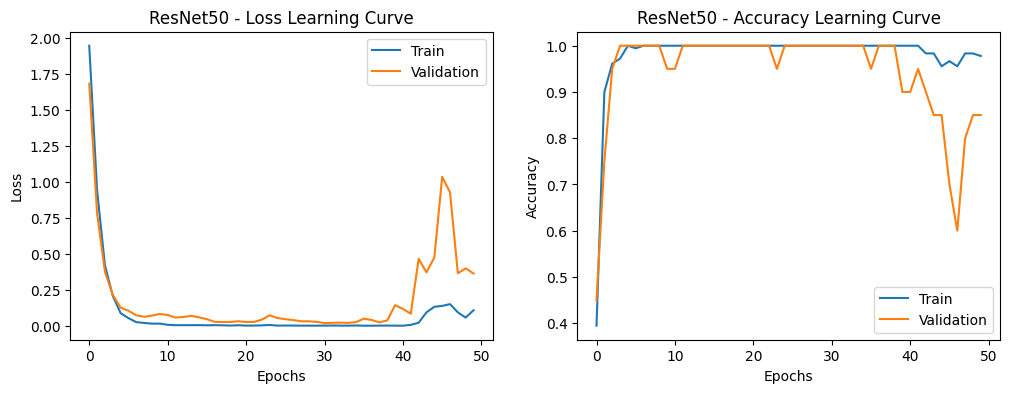

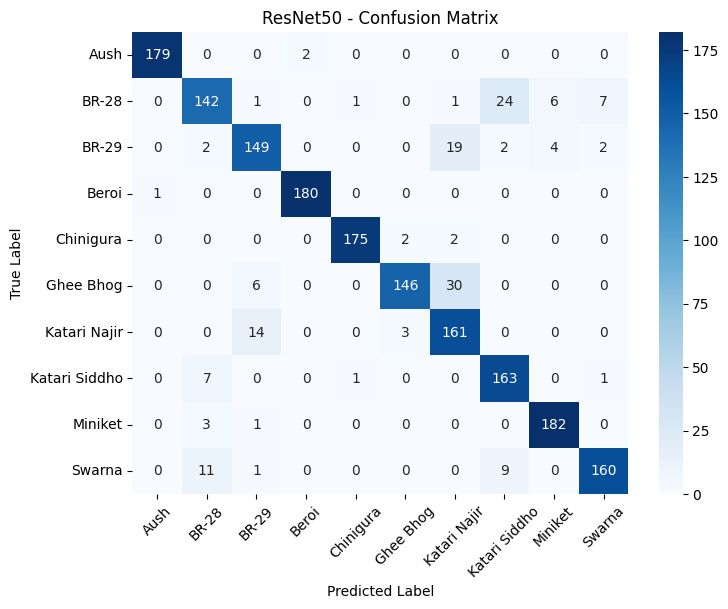

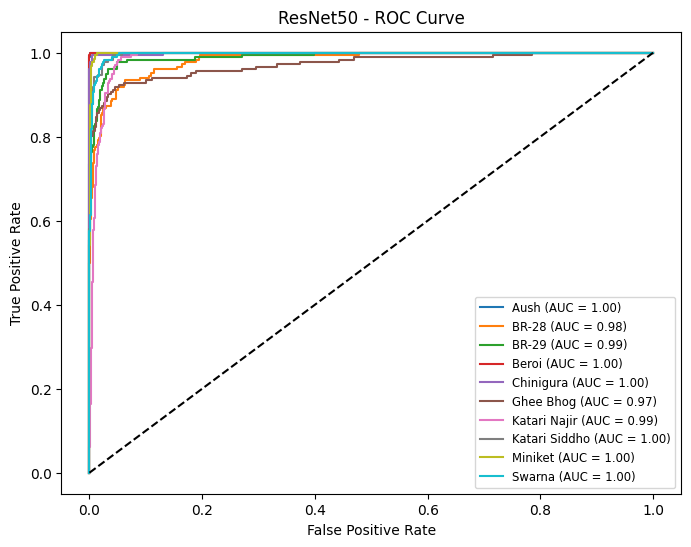


************************************************************
BEST SUPERVISED BASELINE FOR SSL REFERENCE: ResNet50
************************************************************


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,GFLOPs (224x224),Train_Time (s),Test_Time (s),Primary_Failure_Mode
0,ResNet50,0.9094,0.9134,0.9095,0.9093,0.9927,4.1317,127.055,16.8289,None


In [7]:
# Initialize Pipeline
models_dict = get_models(num_classes)
results_list = []
criterion = nn.CrossEntropyLoss()

for model_name, model in models_dict.items():
    print(f"\n{'='*50}\nEvaluating Baseline: {model_name}\n{'='*50}")
    
    # Fixed Input Size GFLOPs Profiling
    gflops = calculate_gflops(model, input_size=(1, 3, 224, 224))
    print(f"[{model_name}] Complexity: {gflops:.3f} GFLOPs")
    
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    
    # 1. Train the model
    trained_model, history, train_time = train_model(model, model_name, criterion, optimizer)
    
    # 2. Plot Learning Curves
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Validation')
    plt.title(f'{model_name} - Loss Learning Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train')
    plt.plot(history['val_acc'], label='Validation')
    plt.title(f'{model_name} - Accuracy Learning Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # 3. Evaluate (Generates CM and ROC plots)
    metrics = evaluate_and_plot(trained_model, model_name, test_loader, num_classes)
    
    metrics['Train_Time (s)'] = train_time
    metrics['GFLOPs (224x224)'] = gflops
    results_list.append(metrics)

# --- FINAL DELIVERABLE TABLE ---
results_df = pd.DataFrame(results_list)
cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 
        'GFLOPs (224x224)', 'Train_Time (s)', 'Test_Time (s)', 'Primary_Failure_Mode']
results_df = results_df[cols]

best_model = results_df.loc[results_df['F1-Score'].idxmax()]['Model']
print(f"\n{'*'*60}")
print(f"BEST SUPERVISED BASELINE FOR SSL REFERENCE: {best_model}")
print(f"{'*'*60}")

# Display Kaggle Summary Table
display(results_df.sort_values(by='F1-Score', ascending=False).round(4))